In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 2 — Look at the data before you model it

Five files, exported from the EPA's animal PFAS database
(USEPA/CPHEA-Animal-PFAS-PK). Each row is one measured serum
concentration. Before fitting anything, you need to know:


```text
how many separate experiments are in here?
what doses, what routes, how long was each followed?
are the points individual animals or group means?
does the decay actually look log-linear?
```

That last question is the one that decides which model you are allowed
to fit. Answer it with your eyes first.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plotting as P
from tk import load, available

P.setup()

pd.set_option("display.width", 200)

## A. Inventory

In [3]:
for name in available():
    df = load(name)
    print(f"   {name:22s} {len(df):5d} rows, {df.dataset.nunique():2d} experiments, "
          f"doses {df.dose_mgkg.min():g}-{df.dose_mgkg.max():g} mg/kg, "
          f"followed to day {df.time_d.max():.0f}")

   PFOA_Female_rat          377 rows, 13 experiments, doses 0.1-320 mg/kg, followed to day 8
   PFOA_Male_primate         43 rows,  1 experiments, doses 10-10 mg/kg, followed to day 123
   PFOA_Male_rat            860 rows, 14 experiments, doses 0.1-48.64 mg/kg, followed to day 84
   PFOS_Male_primate         48 rows,  1 experiments, doses 2-2 mg/kg, followed to day 161
   PFOS_Male_rat            246 rows,  9 experiments, doses 0.1-20 mg/kg, followed to day 140


## B. One clean experiment, in full

In [4]:
print("\n\nB. The cleanest curve in the collection\n")
mk = load("PFOA_Male_primate")
print("   PFOA, male cynomolgus monkeys, Butenhoff et al., 10 mg/kg IV,")
print(f"   3 animals, {mk.time_d.max():.0f} days of follow-up, {len(mk)} measurements.\n")

wide = mk.pivot_table(index="time_d", columns="animal_id", values="conc_mgL")
print(wide.round(2).to_string())



B. The cleanest curve in the collection

   PFOA, male cynomolgus monkeys, Butenhoff et al., 10 mg/kg IV,
   3 animals, 123 days of follow-up, 43 measurements.

animal_id    2052   2054   2211
time_d                         
0.020833    91.13  96.66  91.37
0.083333    67.90  91.63  90.68
0.166667    74.00  89.16  71.96
0.333333    71.20  60.86  73.65
1.000000    50.21  50.93  64.16
2.000000    65.81  48.53  48.93
4.000000    43.37  42.94  30.49
7.000000    45.84  27.91  29.10
11.000000   39.45  19.32  23.64
14.000000   37.36  11.22  13.43
21.000000   33.60   3.99   5.94
28.000000   21.14   1.86   3.24
57.000000   15.01   0.47   0.78
79.000000    9.92    NaN    NaN
87.000000     NaN   0.10   0.11
123.000000    NaN    NaN   0.04


Three things to notice:

1. The animals differ by roughly 2x at the same time point. That is

```text
real between-animal variability, not measurement noise, and it is
the reason serious PK models are hierarchical (each animal gets
its own parameters drawn from a population distribution).
```

2. The first two points are at 0.02 and 0.08 days -- minutes after

```text
the injection. Early points like these carry almost all the
information about DISTRIBUTION; the late ones carry the
information about ELIMINATION.
```

3. Concentrations span three orders of magnitude. Always plot and

```text
fit these on a log scale; on a linear scale the late points, which
determine the half-life, are invisible.
```

## C. Is it a straight line on a log axis?

In [5]:
# Use ONE animal, not the mean across animals. Look at the table above:
# animal 2052 has no sample at day 87, and animals 2054/2211 have none at
# day 79. Averaging over whoever happens to be present makes the mean jump
# around for reasons that have nothing to do with kinetics -- a real and
# very common trap when a study reports group means with varying n.
one = mk[mk.animal_id == 2054].sort_values("time_d")
m = one.set_index("time_d").conc_mgL
lnC = np.log(m.values)
t = m.index.values
print("   animal 2054 only (see the trap noted in the source).\n")

print("   Local slope between consecutive time points (= -k over that gap):\n")
print(f"   {'from':>8s} {'to':>8s} {'C from':>9s} {'C to':>9s} {'-slope':>9s} {'implied t1/2':>13s}")
for i in range(len(t) - 1):
    dt = t[i + 1] - t[i]
    if dt <= 0:
        continue
    slope = (lnC[i + 1] - lnC[i]) / dt
    with np.errstate(divide="ignore"):
        hl = np.log(2) / -slope if slope < 0 else np.inf
    print(f"   {t[i]:8.3f} {t[i+1]:8.3f} {m.values[i]:9.2f} {m.values[i+1]:9.3f} "
          f"{-slope:9.4f} {hl:13.2f}")

   animal 2054 only (see the trap noted in the source).

   Local slope between consecutive time points (= -k over that gap):

       from       to    C from      C to    -slope  implied t1/2
      0.021    0.083     96.66    91.630    0.8551          0.81
      0.083    0.167     91.63    89.160    0.3279          2.11
      0.167    0.333     89.16    60.860    2.2911          0.30
      0.333    1.000     60.86    50.930    0.2672          2.59
      1.000    2.000     50.93    48.530    0.0483         14.36
      2.000    4.000     48.53    42.940    0.0612         11.33
      4.000    7.000     42.94    27.910    0.1436          4.83
      7.000   11.000     27.91    19.320    0.0920          7.54
     11.000   14.000     19.32    11.220    0.1811          3.83
     14.000   21.000     11.22     3.990    0.1477          4.69
     21.000   28.000      3.99     1.860    0.1090          6.36
     28.000   57.000      1.86     0.470    0.0474         14.61
     57.000   87.000      0.

The slope is NOT constant. It is steep in the first day or two and
then settles down. A single exponential cannot do that -- this is the
signature of a second compartment, and it is why lesson 06 exists.

For now, notice the practical consequence: if you fit one exponential
to ALL these points you get a half-life somewhere between the fast
early value and the slow late value, and it depends entirely on where
your sampling happened to stop. Published half-lives disagree partly
for this reason.

## D. The messier case: many experiments in one file

In [6]:
rat = load("PFOA_Male_rat")
summary = (rat.groupby(["dataset", "route", "dose_mgkg"])
              .agg(n=("time_d", "size"), t_max=("time_d", "max"),
                   C_first=("conc_mgL", "first"), C_last=("conc_mgL", "last"))
              .reset_index())
print(summary.round(3).to_string(index=False))

                  dataset  route  dose_mgkg   n  t_max  C_first  C_last
   2990271-20.14 mg/kg-iv     iv      48.63  11 12.000  134.032   9.854
 3749289-1.0 mg/kg-gavage gavage       1.00   9 12.000    5.310   0.110
     3749289-1.0 mg/kg-iv     iv       1.00   9 12.000    5.103   0.460
   3858670-20.14 mg/kg-iv     iv      48.64  10 12.057  130.404  10.016
 3859701-0.1 mg/kg-gavage gavage       0.10  13 28.000    0.013   0.129
5916078-12.0 mg/kg-gavage gavage      12.00  30 50.000   19.600   1.640
5916078-48.0 mg/kg-gavage gavage      48.00  30 50.000   14.100   5.360
 5916078-6.0 mg/kg-gavage gavage       6.00  30 50.000    9.660   2.000
     5916078-6.0 mg/kg-iv     iv       6.00  36 50.000   55.600   0.841
 6302380-0.1 mg/kg-gavage gavage       0.10 288 84.000    0.438   0.004
 6302380-1.0 mg/kg-gavage gavage       1.00 115 22.000    2.054   0.397
     6302380-1.0 mg/kg-iv     iv       1.00  96 22.000   20.170   0.565
6302380-25.0 mg/kg-gavage gavage      25.00  92 22.000   16.375 

This is what real PK data look like: different labs, different doses
spanning 500x, different routes, different follow-up lengths. You
cannot pool these into one curve. Each dataset gets its own fit, and
only then do you ask whether the fitted parameters differ by dose --
which is exactly what ../pfas_dose does.

### E. Figures

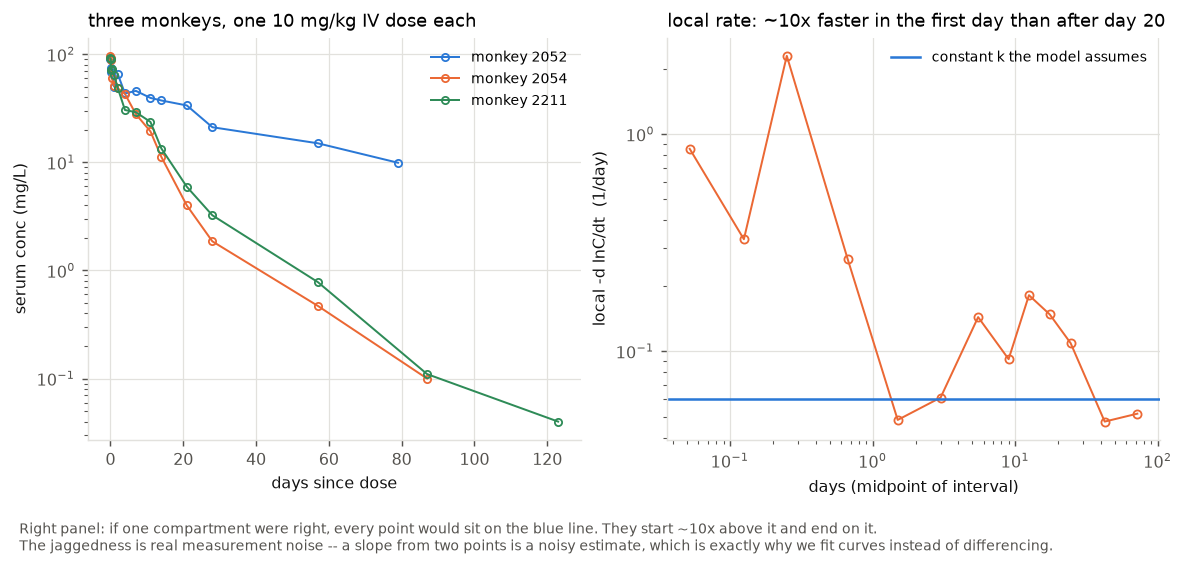

/tmp/ipykernel_1229/1817654134.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(g.time_d, y, "-", color=col, lw=1.2, alpha=0.85,
/tmp/ipykernel_1229/1817654134.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(g.time_d, y, "-", color=col, lw=1.2, alpha=0.85,
/tmp/ipykernel_1229/1817654134.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(g.time_d, y, "-", color=col, lw=1.2, alpha=0.85,
/tmp/ipykernel_1229/1817654134.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.

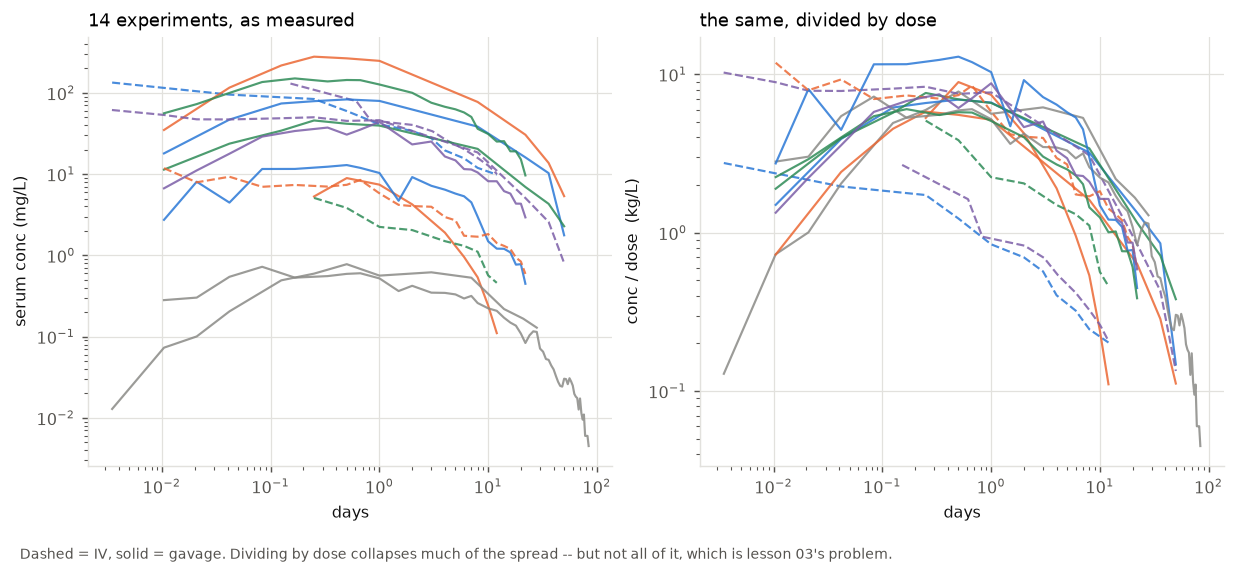

'/home/user/chiu__2022_rerun/tk_learning/figures/02_rat_datasets.png'

In [7]:
# E1 -- the three monkeys, each as its own series, on a log axis.
fig, (a, b) = plt.subplots(1, 2, figsize=(9.0, 3.8), constrained_layout=True)
for aid, col in zip(sorted(mk.animal_id.unique()), P.CYCLE):
    d = mk[mk.animal_id == aid].sort_values("time_d")
    a.plot(d.time_d, d.conc_mgL, "o-", color=col, ms=4, lw=1.1,
           mfc="none", label=f"monkey {aid}")
a.set(yscale="log", xlabel="days since dose", ylabel="serum conc (mg/L)")
a.set_title("three monkeys, one 10 mg/kg IV dose each")
a.legend()

# E2 -- the local slope, which is what a one-compartment model claims is
# constant. Plot it against the MIDPOINT of each interval.
one = mk[mk.animal_id == 2054].sort_values("time_d")
tt, cc = one.time_d.values, one.conc_mgL.values
mid = (tt[1:] + tt[:-1]) / 2
slope = -np.diff(np.log(cc)) / np.diff(tt)
b.plot(mid, slope, "o-", color=P.ORANGE, ms=4.5, lw=1.1, mfc="none")
b.axhline(np.log(2) / 11.5, color=P.BLUE, lw=1.4,
          label="constant k the model assumes")
b.set(xscale="log", yscale="log", xlabel="days (midpoint of interval)",
      ylabel="local -d lnC/dt  (1/day)")
b.set_title("local rate: ~10x faster in the first day than after day 20")
b.legend()
P.save(fig, "02_monkey_curves.png",
       "Right panel: if one compartment were right, every point would sit "
       "on the blue line. They start ~10x above it and end on it.\n"
       "The jaggedness is real measurement noise -- a slope from two "
       "points is a noisy estimate, which is exactly why we fit curves "
       "instead of differencing.")

# E3 -- the messy reality: every male-rat experiment at once.
rat = load("PFOA_Male_rat")
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 4.0), constrained_layout=True)
for (name, g), col in zip(rat.groupby("dataset"), P.CYCLE * 4):
    g = g.groupby("time_d", as_index=False).conc_mgL.mean()
    for ax, norm in [(a, 1.0), (b, None)]:
        dose = rat[rat.dataset == name].dose_mgkg.iloc[0]
        y = g.conc_mgL if norm else g.conc_mgL / dose
        ax.plot(g.time_d, y, "-", color=col, lw=1.2, alpha=0.85,
                ls="--" if "iv" in name else "-")
a.set(xscale="log", yscale="log", xlabel="days", ylabel="serum conc (mg/L)")
a.set_title("14 experiments, as measured")
b.set(xscale="log", yscale="log", xlabel="days",
      ylabel="conc / dose  (kg/L)")
b.set_title("the same, divided by dose")
P.save(fig, "02_rat_datasets.png",
       "Dashed = IV, solid = gavage. Dividing by dose collapses much of "
       "the spread -- but not all of it, which is lesson 03's problem.")

### Questions

1. In section C, why is the early slope steeper than the late one? Where has the chemical gone, if it has not been eliminated?
1. Dataset 6302380-0.1 mg/kg-gavage has 288 observations over 84 days; 3749289-1.0 mg/kg-iv has 9 over 12 days. Which will give a better estimate of the half-life, and why is it not simply "the one with more points"?
1. The IV and gavage arms of study 3749289 used the same dose. What can you learn by comparing them that neither gives on its own?
1. Sex is in the file name, not a column -- male and female rats are fitted separately. Given that female rats clear PFOA ~44x faster, what would happen if you pooled them?

### Exercise

Pick any dataset and repeat section C's consecutive-slope table on it,
and add it to the right-hand panel of 02_monkey_curves.png. Which
experiments look log-linear and which bend? Bending experiments are
the ones that need two compartments.
Then look at 02_rat_datasets.png: if dividing by dose collapsed the
curves PERFECTLY, clearance would be dose-independent. It nearly
does. Measuring the residual gap is what ../pfas_dose spends its
whole analysis on, and the answer is a slope of about 0.1.